## Project Title

Aurora Forecast: When Are the Best Conditions to See the Northern Lights? 

Aurora Forecast is an end-to-end decision support application that combines Machine Learning with multiple real-time and forecast APIs to estimate the probability of observing the Northern Lights anywhere in the world.

## Introduction

The Northern Lights are the visible result of a long chain of physical processes that begins at the Sun and ends in the Earth's atmosphere. Understanding this sequence is essential to predicting when auroras are most likely to occur.

My previous machine learning project focused on the first stage of the process: predicting whether a Coronal Mass Ejection (CME) would become geoeffective. This project moves one step further along the chain by modelling the actual space weather conditions measured near Earth and predicting the resulting geomagnetic storm intensity. Together, the two projects represent different stages of the same physical process.

Now, instead of analysing the solar eruption, we focus on the space weather conditions measured near Earth, including solar wind speed, density, temperature, magnetic field measurements and sunspot activity. These variables represent the actual environment interacting with the Earth's magnetosphere.

Using these measurements, the project predicts the Disturbance Storm Time (Dst) index, which indicates the strength of geomagnetic storms. Stronger storms generally create better conditions for auroras, so the predicted Dst helps estimate the chances of seeing the Northern Lights.

The project integrates this Machine Learning prediction into a Streamlit application alongside real-time and forecast API data. The model provides a real-time estimate of current geomagnetic storm intensity, while the application separately combines forecast space weather, darkness and local atmospheric conditions to estimate the chances of observing the Northern Lights for a selected location and date.

This project is based on publicly available NASA space weather data integrated into a unified dataset.

## Problem Statement

People who want to see the Northern Lights often need to consult multiple sources of information, including space weather, geomagnetic activity, weather forecasts and darkness conditions. This process is time-consuming and difficult for non-experts.

The goal of this project is to simplify that process by providing a single application that estimates the probability of observing the Northern Lights for a selected location and forecast date.

## Project Goal

Develop an end-to-end Machine Learning project that predicts current geomagnetic storm intensity using real-time space weather data and integrates this prediction into a Streamlit application that also provides personalized aurora forecasts for a selected location and date using space weather and environmental API data.

This project builds on my previous Machine Learning project, which focused on predicting whether a Coronal Mass Ejection (CME) would become geoeffective. Instead of modelling the CME itself, this project predicts the resulting geomagnetic storm intensity (Dst index) using current space weather conditions. This real-time prediction is presented as Today’s ML Aurora Estimate, while forecasts for selected locations and dates are calculated separately using forecast geomagnetic activity, location, darkness and atmospheric conditions.

The initial idea was to combine the Machine Learning model directly with forecast APIs to generate predictions for future dates. However, the specific solar wind and magnetic field variables required by the trained model are difficult to obtain as forecast data, particularly across longer time horizons. For this reason, the final application uses the Machine Learning model with real-time NOAA measurements, while future forecasts rely on the NOAA 45-Day Ap forecast together with location, darkness and atmospheric conditions.

## Research Question

Can data help users identify the best conditions to observe the Northern Lights?

## Data Selection & Loading

The first step of the project is to load the datasets provided.

These datasets contain complementary information about space weather and are based on publicly available observations from NASA and internationally maintained scientific datasets:

- **labels:** geomagnetic activity measurements (Dst index).
- **solar_wind:** solar wind measurements collected every minute.
- **sunspots:** historical sunspot activity.

Before building the Machine Learning model, we need to understand, clean and combine these datasets into a single dataset suitable for analysis.

In [89]:
import pandas as pd

labels = pd.read_csv("Datasets/labels.csv")
solar_wind = pd.read_csv("Datasets/solar_wind.csv")
sunspots = pd.read_csv("Datasets/sunspots.csv")

## Datasets Overview

Before cleaning and combining the datasets, we inspected their structure, variables and data types to better understand the available information.

In [90]:
labels.info()

<class 'pandas.DataFrame'>
RangeIndex: 139872 entries, 0 to 139871
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   period     139872 non-null  str  
 1   timedelta  139872 non-null  str  
 2   dst        139872 non-null  int64
dtypes: int64(1), str(2)
memory usage: 6.5 MB


In [91]:
labels.head()

,period,timedelta,dst
0,train_a,0 days 00:00:00,-7
1,train_a,0 days 01:00:00,-10
2,train_a,0 days 02:00:00,-10
3,train_a,0 days 03:00:00,-6
4,train_a,0 days 04:00:00,-2


In [92]:
solar_wind.info()

<class 'pandas.DataFrame'>
RangeIndex: 8392320 entries, 0 to 8392319
Data columns (total 17 columns):
 #   Column       Dtype  
---  ------       -----  
 0   period       str    
 1   timedelta    str    
 2   bx_gse       float64
 3   by_gse       float64
 4   bz_gse       float64
 5   theta_gse    float64
 6   phi_gse      float64
 7   bx_gsm       float64
 8   by_gsm       float64
 9   bz_gsm       float64
 10  theta_gsm    float64
 11  phi_gsm      float64
 12  bt           float64
 13  density      float64
 14  speed        float64
 15  temperature  float64
 16  source       str    
dtypes: float64(14), str(3)
memory usage: 1.3 GB


In [93]:
solar_wind.head()

,period,timedelta,bx_gse,by_gse,bz_gse,theta_gse,phi_gse,bx_gsm,by_gsm,bz_gsm,theta_gsm,phi_gsm,bt,density,speed,temperature,source
0,train_a,0 days 00:00:00,-5.55,3.00,1.25,11.09,153.37,-5.55,3.00,1.25,11.09,153.37,6.80,1.53,383.92,110237.0,ac
1,train_a,0 days 00:01:00,-5.58,3.16,1.17,10.10,151.91,-5.58,3.16,1.17,10.10,151.91,6.83,1.69,381.79,123825.0,ac
2,train_a,0 days 00:02:00,-5.15,3.66,0.85,7.87,146.04,-5.15,3.66,0.85,7.87,146.04,6.77,1.97,389.11,82548.0,ac
3,train_a,0 days 00:03:00,-5.20,3.68,0.68,6.17,146.17,-5.20,3.68,0.68,6.17,146.17,6.74,1.97,389.11,82548.0,ac
4,train_a,0 days 00:04:00,-5.12,3.68,0.49,4.62,145.72,-5.12,3.68,0.49,4.62,145.72,6.65,1.77,384.26,94269.0,ac


In [94]:
sunspots.info()

<class 'pandas.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   period        192 non-null    str    
 1   timedelta     192 non-null    str    
 2   smoothed_ssn  192 non-null    float64
dtypes: float64(1), str(2)
memory usage: 9.2 KB


In [95]:
sunspots.head()

,period,timedelta,smoothed_ssn
0,train_a,0 days 00:00:00,65.4
1,train_a,13 days 00:00:00,72.0
2,train_a,44 days 00:00:00,76.9
3,train_a,74 days 00:00:00,80.8
4,train_a,105 days 00:00:00,85.4


### Key Observation

The three datasets have different temporal resolutions:

- `solar_wind` records measurements every minute.
- `labels` provides hourly geomagnetic storm values (Dst).
- `sunspots` is updated approximately every few weeks.

Therefore, the datasets cannot be merged directly and will require temporal alignment before model training.

## Data Cleaning

### Missing Values

In [96]:
labels.isna().sum()
solar_wind.isna().sum()
sunspots.isna().sum()

print("Labels")
print(labels.isna().sum())

print("\nSolar Wind")
print(solar_wind.isna().sum())

print("\nSunspots")
print(sunspots.isna().sum())

Labels
period       0
timedelta    0
dst          0
dtype: int64

Solar Wind
period              0
timedelta           0
bx_gse         325888
by_gse         325888
bz_gse         325888
theta_gse      325888
phi_gse        326388
bx_gsm         325888
by_gsm         325888
bz_gsm         325888
theta_gsm      325888
phi_gsm        326388
bt             325888
density        684890
speed          689555
temperature    811768
source         316816
dtype: int64

Sunspots
period          0
timedelta       0
smoothed_ssn    0
dtype: int64


The `labels` and `sunspots` datasets contain no missing values. Missing values were identified in `solar_wind` and will be analyzed to determine the most appropriate preprocessing strategy.

In [97]:
# Let's see the percentage of missing data it has

(solar_wind.isna().mean() * 100).round(2).sort_values(ascending=False)

temperature    9.67
speed          8.22
density        8.16
phi_gsm        3.89
phi_gse        3.89
bt             3.88
bx_gse         3.88
bz_gse         3.88
by_gse         3.88
bz_gsm         3.88
by_gsm         3.88
theta_gse      3.88
bx_gsm         3.88
theta_gsm      3.88
source         3.78
period         0.00
timedelta      0.00
dtype: float64

The percentage of missing values in `solar_wind` is relatively low (below 10% for all variables). Therefore, the missing values will be handled during preprocessing rather than removing the affected observations.

In [98]:
# Check duplicates

labels.duplicated().sum()
solar_wind.duplicated().sum()
sunspots.duplicated().sum()

print("Labels")
print(labels.duplicated().sum())

print("\nSolar Wind")
print(solar_wind.duplicated().sum())

print("\nSunspots")
print(sunspots.duplicated().sum())

Labels
0

Solar Wind
0

Sunspots
0


### Data Types

In [99]:
labels.dtypes
solar_wind.dtypes
sunspots.dtypes

print("Labels")
print(labels.dtypes)

print("\nSolar Wind")
print(solar_wind.dtypes)

print("\nSunspots")
print(sunspots.dtypes)

Labels
period         str
timedelta      str
dst          int64
dtype: object

Solar Wind
period             str
timedelta          str
bx_gse         float64
by_gse         float64
bz_gse         float64
theta_gse      float64
phi_gse        float64
bx_gsm         float64
by_gsm         float64
bz_gsm         float64
theta_gsm      float64
phi_gsm        float64
bt             float64
density        float64
speed          float64
temperature    float64
source             str
dtype: object

Sunspots
period              str
timedelta           str
smoothed_ssn    float64
dtype: object


Most variables already have appropriate data types. The `timedelta` column is currently stored as a string and will be converted to a proper timedelta format before merging the datasets.

In [100]:
labels["timedelta"] = pd.to_timedelta(labels["timedelta"])
solar_wind["timedelta"] = pd.to_timedelta(solar_wind["timedelta"])
sunspots["timedelta"] = pd.to_timedelta(sunspots["timedelta"])

In [101]:
print(labels["timedelta"].dtype)
print(solar_wind["timedelta"].dtype)
print(sunspots["timedelta"].dtype)

timedelta64[us]
timedelta64[us]
timedelta64[us]


## Data Integration

The selected datasets have different temporal resolutions and therefore cannot be merged directly.

To create a unified dataset suitable for Machine Learning, the datasets will be aligned to the same hourly frequency before being merged using the common keys `period` and `timedelta`.

In [102]:
labels["timedelta"].diff().value_counts().head()

timedelta
0 days 01:00:00         139869
-1201 days +01:00:00         1
-2191 days +01:00:00         1
Name: count, dtype: int64

In [103]:
solar_wind["timedelta"].diff().value_counts().head()

timedelta
0 days 00:01:00         8392317
-1201 days +00:01:00          1
-2191 days +00:01:00          1
Name: count, dtype: int64

In [104]:
sunspots["timedelta"].diff().value_counts().head()

timedelta
31 days    109
30 days     64
28 days     12
29 days      3
13 days      1
Name: count, dtype: int64

### Aggregating Solar Wind Data

The `solar_wind` dataset contains measurements recorded every minute, while the target variable (`Dst`) is available hourly.

To align both datasets, the minute-level measurements are aggregated into hourly averages for each period.

In [105]:
# Create an hourly version of the timedelta column
solar_wind["timedelta_hour"] = solar_wind["timedelta"].dt.floor("h")

# Aggregate minute-level measurements to hourly averages
solar_wind_hourly = (
    solar_wind
    .groupby(["period", "timedelta_hour"], as_index=False)
    .mean(numeric_only=True)
)

# Rename the key to match the other datasets
solar_wind_hourly = solar_wind_hourly.rename(
    columns={"timedelta_hour": "timedelta"}
)

In [106]:
# Let's check it

solar_wind_hourly.head()

,period,timedelta,bx_gse,by_gse,bz_gse,theta_gse,phi_gse,bx_gsm,by_gsm,bz_gsm,theta_gsm,phi_gsm,bt,density,speed,temperature
0,train_a,0 days 00:00:00,-6.149500,1.645500,0.844667,7.103667,165.420333,-6.149500,1.645500,0.844667,7.103667,165.420333,7.140000,1.222692,356.591538,71071.403846
1,train_a,0 days 01:00:00,-6.693833,0.766500,1.265167,10.183333,174.267833,-6.693833,0.766500,1.265167,10.183333,174.267833,7.284833,0.868727,331.800545,59333.209302
2,train_a,0 days 02:00:00,-7.222167,0.781167,2.200167,16.236667,174.391000,-7.222167,0.781167,2.200167,16.236667,174.391000,7.872833,0.932500,329.140962,48582.368421
3,train_a,0 days 03:00:00,-6.868833,-1.272667,1.770333,13.169333,190.415167,-6.868833,-1.272667,1.770333,13.169333,190.415167,7.748333,2.754211,347.815088,76768.736842
4,train_a,0 days 04:00:00,-5.256818,0.376818,1.327273,12.510000,175.608636,-5.256818,0.376818,1.327273,12.510000,175.608636,6.298636,2.889500,370.297500,78039.550000


In [107]:
# Let's check it

solar_wind_hourly.shape

(139872, 16)

### Temporal Alignment

The datasets were recorded at different temporal resolutions:

- `labels` contains hourly Dst values.
- `solar_wind` contains measurements recorded every minute.
- `sunspots` contains observations approximately every month.

To ensure a consistent merge, the `solar_wind` dataset was aggregated to an hourly frequency by calculating the mean of all numerical variables within each hour. The resulting dataset contains the same number of hourly observations as the `labels` dataset (139,872 rows), confirming that both datasets are now temporally aligned and ready to be merged.

### Merging the Datasets

After aligning the temporal resolution, the datasets are merged using the common keys `period` and `timedelta` to create a single dataset for analysis and Machine Learning.

In [108]:
# Merge labels with hourly solar wind data
aurora_df = labels.merge(
    solar_wind_hourly,
    on=["period", "timedelta"],
    how="left"
)

In [109]:
# Let's check it

aurora_df.shape

(139872, 17)

In [110]:
aurora_df.head()

,period,timedelta,dst,bx_gse,by_gse,bz_gse,theta_gse,phi_gse,bx_gsm,by_gsm,bz_gsm,theta_gsm,phi_gsm,bt,density,speed,temperature
0,train_a,0 days 00:00:00,-7,-6.149500,1.645500,0.844667,7.103667,165.420333,-6.149500,1.645500,0.844667,7.103667,165.420333,7.140000,1.222692,356.591538,71071.403846
1,train_a,0 days 01:00:00,-10,-6.693833,0.766500,1.265167,10.183333,174.267833,-6.693833,0.766500,1.265167,10.183333,174.267833,7.284833,0.868727,331.800545,59333.209302
2,train_a,0 days 02:00:00,-10,-7.222167,0.781167,2.200167,16.236667,174.391000,-7.222167,0.781167,2.200167,16.236667,174.391000,7.872833,0.932500,329.140962,48582.368421
3,train_a,0 days 03:00:00,-6,-6.868833,-1.272667,1.770333,13.169333,190.415167,-6.868833,-1.272667,1.770333,13.169333,190.415167,7.748333,2.754211,347.815088,76768.736842
4,train_a,0 days 04:00:00,-2,-5.256818,0.376818,1.327273,12.510000,175.608636,-5.256818,0.376818,1.327273,12.510000,175.608636,6.298636,2.889500,370.297500,78039.550000


### Merging Sunspot Data

The `sunspots` dataset has a much lower temporal resolution than the other datasets. To preserve all hourly observations, each record is matched with the most recent available sunspot measurement within the same period.

In [111]:
# Exact merge
aurora_df = aurora_df.merge(
    sunspots,
    on=["period", "timedelta"],
    how="left"
)

# Propagate the latest available sunspot value
aurora_df["smoothed_ssn"] = (
    aurora_df
    .groupby("period")["smoothed_ssn"]
    .ffill()
    .bfill()
)

In [112]:
aurora_df.shape

(139872, 18)

In [113]:
aurora_df[["timedelta", "smoothed_ssn"]].head(20)

,timedelta,smoothed_ssn
0,0 days 00:00:00,65.4
1,0 days 01:00:00,65.4
2,0 days 02:00:00,65.4
3,0 days 03:00:00,65.4
4,0 days 04:00:00,65.4
5,0 days 05:00:00,65.4
6,0 days 06:00:00,65.4
7,0 days 07:00:00,65.4
8,0 days 08:00:00,65.4
9,0 days 09:00:00,65.4


In [114]:
aurora_df.isna().sum().sort_values(ascending=False)

temperature     3328
density         3244
speed           3244
by_gsm          2548
bt              2548
bx_gse          2548
bx_gsm          2548
by_gse          2548
bz_gse          2548
theta_gse       2548
theta_gsm       2548
phi_gsm         2548
phi_gse         2548
bz_gsm          2548
timedelta          0
period             0
dst                0
smoothed_ssn       0
dtype: int64

In [115]:
aurora_df.to_csv("Datasets/aurora_dataset.csv", index=False)

## Integrated Dataset

After merging the original NASA datasets and performing the initial preprocessing, the resulting integrated dataset was exported as aurora_dataset.csv. This file serves as the final working dataset for the subsequent exploratory analysis and Machine Learning pipeline.

## Exploratory Data Analysis (EDA)

After cleaning and integrating the datasets into a single dataframe, the next step is to explore the data.

The objective of this analysis is to understand the distribution of the target variable, identify patterns and relationships between features, detect potential outliers, and gain insights that will guide the preprocessing and model selection stages.

## Dataset Overview

In [116]:
aurora_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 139872 entries, 0 to 139871
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype          
---  ------        --------------   -----          
 0   period        139872 non-null  str            
 1   timedelta     139872 non-null  timedelta64[us]
 2   dst           139872 non-null  int64          
 3   bx_gse        137324 non-null  float64        
 4   by_gse        137324 non-null  float64        
 5   bz_gse        137324 non-null  float64        
 6   theta_gse     137324 non-null  float64        
 7   phi_gse       137324 non-null  float64        
 8   bx_gsm        137324 non-null  float64        
 9   by_gsm        137324 non-null  float64        
 10  bz_gsm        137324 non-null  float64        
 11  theta_gsm     137324 non-null  float64        
 12  phi_gsm       137324 non-null  float64        
 13  bt            137324 non-null  float64        
 14  density       136628 non-null  float64        
 15  speed      

In [117]:
aurora_df.describe().T

,count,mean,std,min,25%,50%,75%,max
timedelta,139872,1044 days 16:12:24.955387,660 days 08:06:21.601879,0 days 00:00:00,485 days 15:45:00,971 days 07:30:00,1584 days 23:15:00,2435 days 23:00:00
dst,139872.0,-11.055236,19.069327,-387.0,-18.0,-8.0,0.0,67.0
bx_gse,137324.0,-0.667338,3.428062,-42.004,-3.103,-0.661917,1.823551,30.366833
by_gse,137324.0,0.110675,3.658576,-32.728167,-2.229875,0.120333,2.404333,38.053051
bz_gse,137324.0,-0.021917,2.885181,-46.67,-1.331,0.007564,1.326208,37.3625
theta_gse,137324.0,0.172726,26.444997,-85.014833,-17.322833,0.121667,17.547417,85.658833
phi_gse,137324.0,194.122226,78.849362,1.195833,133.839792,177.104417,268.539792,358.611833
bx_gsm,137324.0,-0.667189,3.425801,-41.962167,-3.100708,-0.6615,1.821667,30.369
by_gsm,137324.0,0.089452,3.581881,-32.3275,-2.151054,0.093,2.2897,37.791695
bz_gsm,137324.0,-0.028506,2.982631,-48.414833,-1.453,-0.001167,1.450542,38.252333


### Key Variables

To keep the analysis accessible, the following sections focus on the variables that are most directly related to the aurora formation process:

- **Disturbance Storm Time (Dst) index:** measures how disturbed the Earth's magnetic field is, with more negative values indicating stronger geomagnetic storms.
- **Speed:** velocity of the solar wind.
- **Density:** number of charged particles in the solar wind.
- **Temperature:** energy of the solar wind plasma.
- **Sunspot Number:** indicator of overall solar activity.

In [118]:
key_variables = aurora_df[
    [
        "dst",
        "speed",
        "density",
        "temperature",
        "smoothed_ssn"
    ]
]

key_variables.describe().T

,count,mean,std,min,25%,50%,75%,max
dst,139872.0,-11.055236,19.069327,-387.0,-18.000000,-8.000000,0.000000,6.700000e+01
speed,136628.0,430.312768,99.819844,0.0,356.715302,409.502948,484.944698,1.021104e+03
density,136628.0,4.420884,4.122317,0.0,1.849265,3.368966,5.691866,1.487850e+02
temperature,136544.0,113360.379651,112690.929261,0.0,41773.636315,78100.511912,149001.009698,2.410815e+06
smoothed_ssn,139872.0,58.086857,52.457739,2.2,14.000000,38.900000,96.400000,1.752000e+02


The selected variables provide a concise overview of the space weather conditions recorded in the dataset.

The **Disturbance Storm Time (Dst) index** has an average value of **-11** and a median of **-8**, indicating that the Earth's magnetic field remains relatively stable most of the time. However, the minimum value reaches **-387**, showing that the dataset also includes rare but extremely intense geomagnetic storms.

The **solar wind speed** varies from **0** to more than **1,000 km/s**, reflecting both quiet solar conditions and high-speed solar wind streams associated with geomagnetic disturbances.

Similarly, **solar wind density** and **temperature** span a broad range of values, indicating that the dataset captures very different space weather environments rather than only typical conditions.

Finally, the **Sunspot Number** ranges from **2.2** to **175.2**, confirming that the observations cover periods of both low and high solar activity.

### Distribution of the Disturbance Storm Time (Dst) Index

In [119]:
aurora_df["dst"].median()

np.float64(-8.0)

In [120]:
aurora_df["dst"].skew()

np.float64(-3.2112775982145365)

In [121]:
aurora_df["dst"].kurtosis()

np.float64(26.861010980601325)

The **median** value of the **Disturbance Storm Time (Dst) index** is **-8**, indicating that most observations correspond to relatively quiet geomagnetic conditions. Although calm conditions dominate the dataset, occasional geomagnetic storms produce much lower values.

This is confirmed by the **negative skewness (-3.21)**, which shows that the distribution is not symmetric. Instead, it has a long left tail created by a relatively small number of intense geomagnetic storms with very negative Dst values.

The **high kurtosis (26.86)** further indicates that these extreme events occur more frequently than would be expected in a typical bell-shaped (normal) distribution. In other words, while most observations represent quiet geomagnetic conditions, the dataset also contains several unusually intense storms that are important for understanding and predicting space weather.

### Visualizations

The following visualizations help us understand how geomagnetic activity is distributed throughout the dataset and whether extreme geomagnetic storms are common or rare.

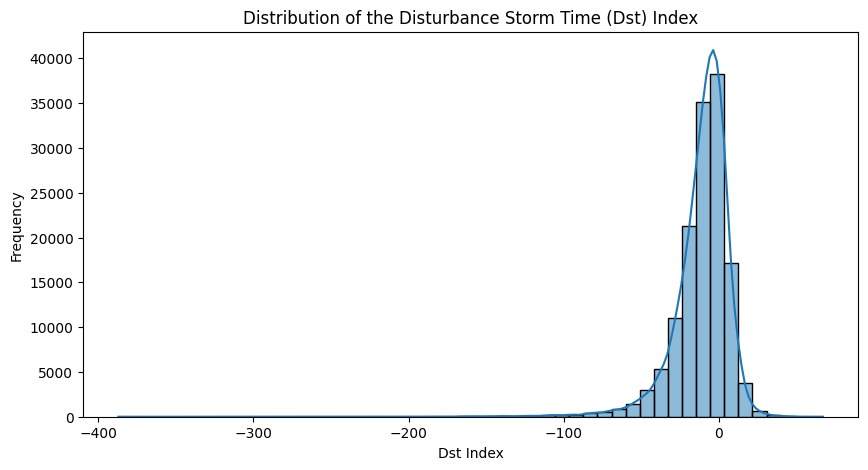

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.histplot(
    aurora_df["dst"],
    bins=50,
    kde=True
)

plt.title("Distribution of the Disturbance Storm Time (Dst) Index")
plt.xlabel("Dst Index")
plt.ylabel("Frequency")

plt.show()

The histogram confirms that the **Disturbance Storm Time (Dst) index** is **not normally distributed**.

Most observations are concentrated around values close to **0** and **-8**, indicating that relatively quiet geomagnetic conditions are the most common. As expected, the distribution has a **long left tail**, showing that strong geomagnetic storms occur much less frequently than calm conditions.

A small number of observations reach very low Dst values (below **-100** and even close to **-400**). These represent rare but extremely intense geomagnetic storms, explaining the negative skewness and the high kurtosis observed in the previous statistical summary.

Overall, the histogram confirms that the dataset is dominated by quiet geomagnetic periods while still containing enough extreme events to study and model severe space weather.

This pattern is expected, as geomagnetic storms—and therefore favourable conditions for observing the Northern Lights—are naturally much less common than quiet space weather conditions.

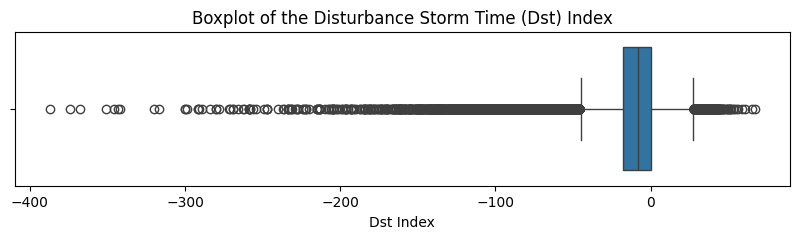

In [123]:
plt.figure(figsize=(10, 2))

sns.boxplot(x=aurora_df["dst"])

plt.title("Boxplot of the Disturbance Storm Time (Dst) Index")
plt.xlabel("Dst Index")

plt.show()

The boxplot highlights the presence of numerous **outliers**, particularly on the left side of the distribution.

Most observations are concentrated within a relatively narrow range around quiet geomagnetic conditions, while a large number of isolated points correspond to unusually low Disturbance Storm Time (Dst) values. These represent **rare but intense geomagnetic storms**.

The strong concentration of outliers on the negative side confirms that extreme storms are much less common than quiet periods, but they are an important part of the dataset. Rather than representing data errors, these observations correspond to real space weather events and are therefore valuable for training a model capable of predicting severe geomagnetic activity.

### Distribution of the Key Variables

The following histograms illustrate the distribution of the main variables involved in the aurora formation process. Understanding their range and shape helps identify common conditions, potential outliers and whether any transformations may be needed during preprocessing.


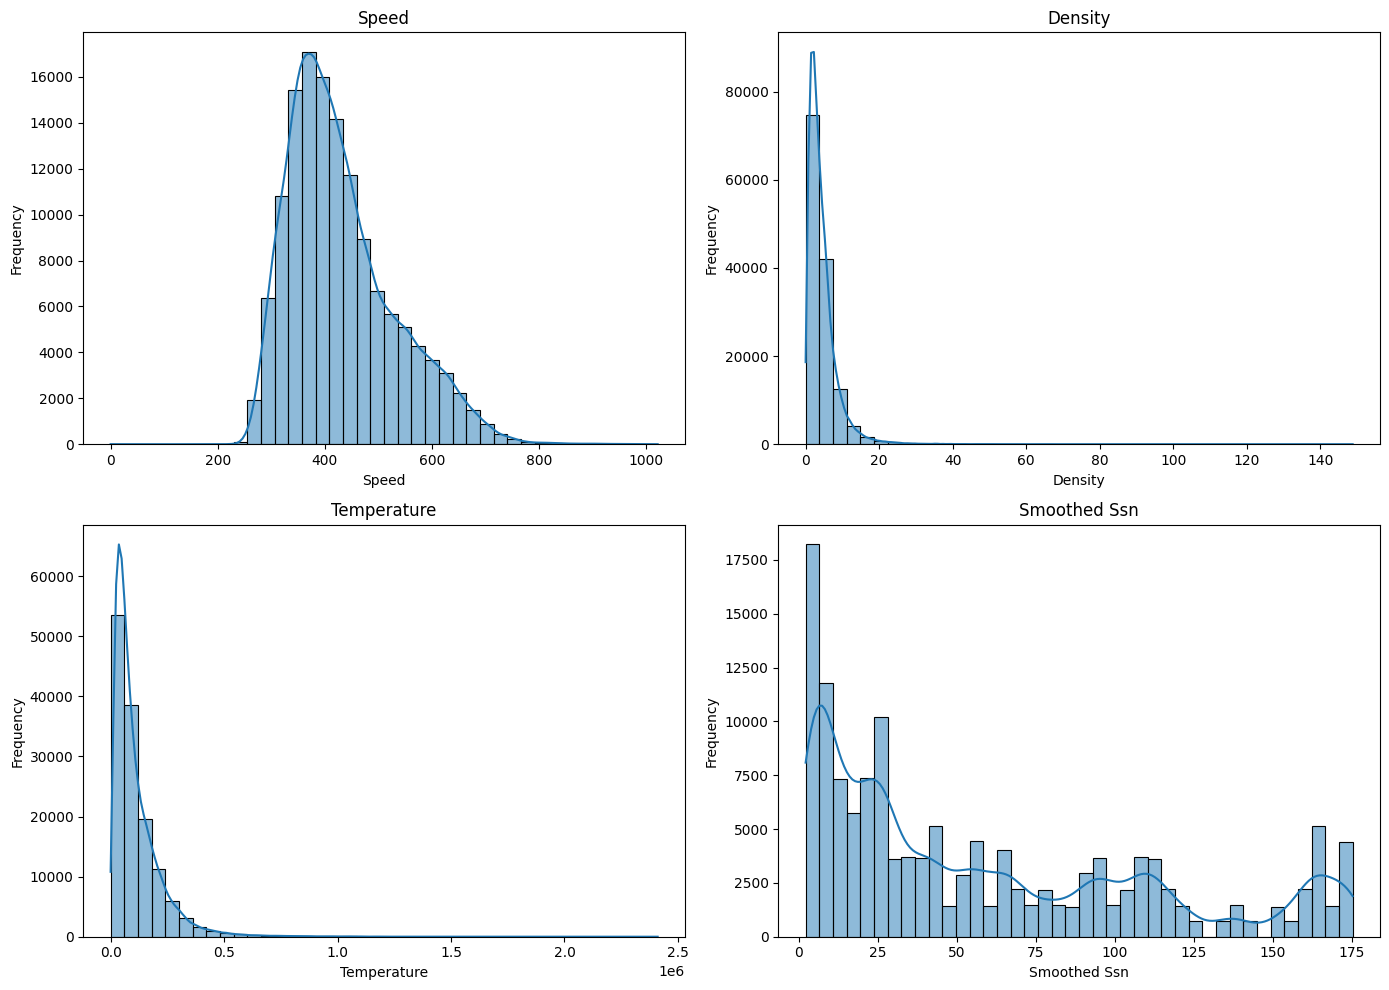

In [124]:
key_variables = ["speed", "density", "temperature", "smoothed_ssn"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, variable in zip(axes.flatten(), key_variables):
    sns.histplot(
        aurora_df[variable],
        bins=40,
        kde=True,
        ax=ax
    )

    ax.set_title(variable.replace("_", " ").title())
    ax.set_xlabel(variable.replace("_", " ").title())
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

The distributions of the key variables reveal that different aspects of space weather behave differently.

The **solar wind speed** shows a moderately right-skewed distribution. Most observations fall between approximately **300 and 500 km/s**, representing the typical speed of the continuous solar wind emitted by the Sun. Higher speeds occur much less frequently and are usually associated with energetic solar events, such as **Coronal Mass Ejections (CMEs)** or high-speed solar wind streams, which can significantly disturb the Earth's magnetic field.

Both **solar wind density** and **temperature** are strongly right-skewed. Under normal conditions, the Sun continuously releases a relatively stable flow of particles with moderate density and energy. However, during powerful solar eruptions, the number of charged particles and their energy can increase dramatically. As a result, most observations remain concentrated at low values, while only a small number correspond to these rare but highly energetic events.

Unlike the other variables, the **Sunspot Number** does not follow a bell-shaped distribution. Instead, it exhibits several peaks that reflect the natural solar cycle, during which the Sun alternates between periods of low and high activity over time.

Overall, these distributions are consistent with the physics of space weather. The Sun behaves relatively calmly most of the time, while intense solar events occur only occasionally. These rare events are precisely the ones capable of triggering strong geomagnetic storms and increasing the probability of observing the Northern Lights.

### Correlation Between Variables

Correlation measures the strength and direction of the linear relationship between numerical variables. Examining the correlation matrix helps identify which variables tend to change together and provides an initial indication of which features may be more closely associated with geomagnetic activity.

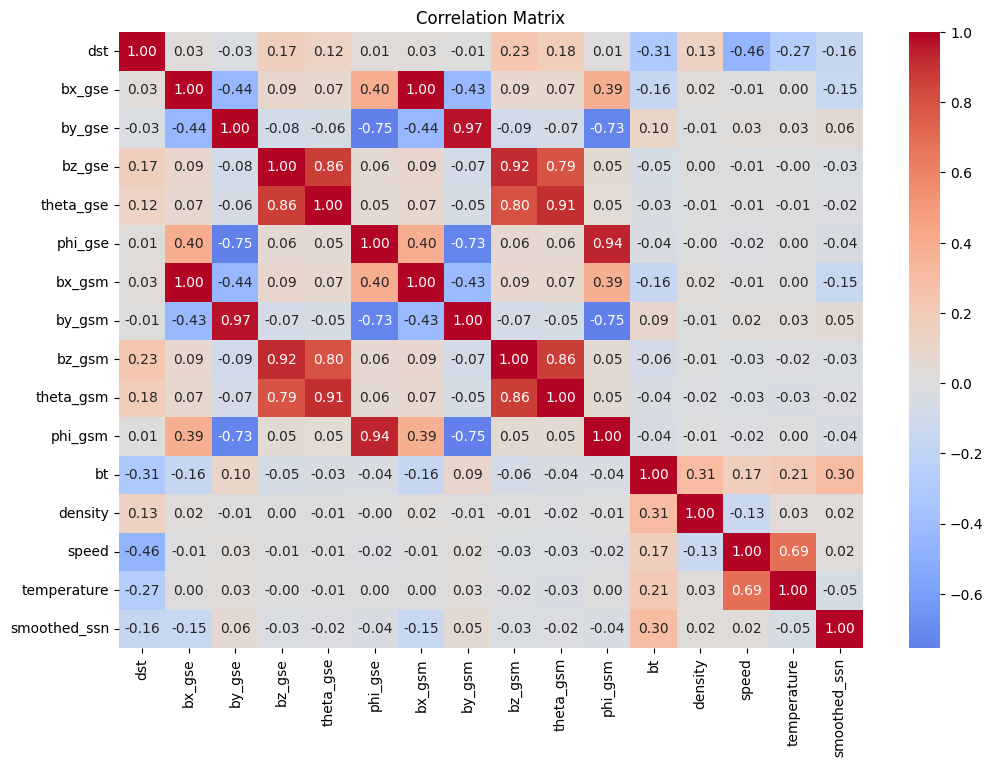

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

correlation_matrix = aurora_df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

The correlation matrix helps us understand which variables tend to change together. A **positive correlation** means that two variables generally increase or decrease at the same time, while a **negative correlation** means that when one variable increases, the other tends to decrease.

The strongest relationship with the **Disturbance Storm Time (Dst) index** is observed for **solar wind speed** (**-0.46**). This negative correlation has a clear physical explanation. When the solar wind travels faster, it carries more energy towards the Earth. This energy interacts with the Earth's magnetic field, making the Disturbance Storm Time (Dst) index more negative and indicating stronger geomagnetic storms. Although speed alone does not determine geomagnetic activity, it is one of the most influential factors.

A weaker negative correlation is also observed between the Disturbance Storm Time (Dst) index and **solar wind temperature** (**-0.27**). This suggests that hotter solar wind is often associated with more energetic solar events, which can contribute to stronger geomagnetic disturbances.

In contrast, **solar wind density** (**0.13**) and the **Sunspot Number** (**-0.16**) show only weak relationships with the Disturbance Storm Time (Dst) index. This indicates that these variables alone are poor predictors of geomagnetic activity. For example, a high number of sunspots does not necessarily produce a geomagnetic storm on Earth, as the solar eruption must also be directed towards our planet and interact effectively with the Earth's magnetic field.

Several magnetic field variables measured in the **Geocentric Solar Ecliptic (GSE)** and **Geocentric Solar Magnetospheric (GSM)** coordinate systems show very strong correlations with each other. This is expected because they represent the same interplanetary magnetic field, but viewed from different reference systems. The GSE system is aligned with the Earth–Sun direction, while the GSM system is aligned with the Earth's magnetic field. Since both systems observe the same physical magnetic field, their measurements naturally change together, leading to strong correlations rather than representing independent physical phenomena.

Overall, the correlation analysis highlights that geomagnetic storms are not caused by a single factor. Instead, they result from the interaction of multiple characteristics of the solar wind and the Earth's magnetic field. This provides a strong justification for using a Machine Learning model, which can learn complex relationships between several variables rather than relying on a single measurement.

### Solar Wind Speed and Geomagnetic Storm Intensity

The correlation analysis identified **solar wind speed** as the variable most strongly associated with the **Disturbance Storm Time (Dst) index**. The following scatter plot visualises this relationship and illustrates the physical process linking solar activity to the Northern Lights.

**Faster solar wind → More energetic interaction with the Earth's magnetosphere → More negative Disturbance Storm Time (Dst) values → Higher probability of observing the Northern Lights**

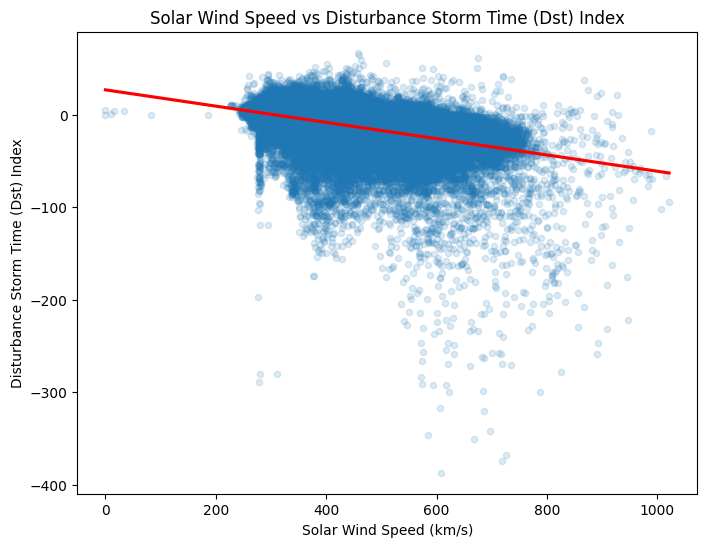

In [126]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=aurora_df,
    x="speed",
    y="dst",
    scatter_kws={"alpha": 0.15, "s": 20},
    line_kws={"color": "red"}
)


plt.title("Solar Wind Speed vs Disturbance Storm Time (Dst) Index")
plt.xlabel("Solar Wind Speed (km/s)")
plt.ylabel("Disturbance Storm Time (Dst) Index")

plt.show()

The scatter plot confirms the moderate negative relationship observed in the correlation analysis. Although the data show considerable variability, a clear downward trend is visible: higher solar wind speeds are generally associated with more negative Disturbance Storm Time (Dst) values, indicating stronger geomagnetic storms.

The plot also suggests that the most intense geomagnetic storms are more frequently observed when the solar wind exceeds approximately **600 km/s**. This is consistent with the physical process in which faster solar wind transports more energy towards the Earth's magnetosphere.

However, the wide dispersion of the observations indicates that solar wind speed alone is not sufficient to explain geomagnetic activity. Other factors, particularly the orientation and strength of the interplanetary magnetic field, also influence how the Earth's magnetosphere responds to incoming solar wind.

## Data Preprocessing

Before training the Machine Learning models, the dataset must be prepared to ensure that all features are suitable for modelling.

This stage includes handling missing values, selecting the predictor variables, defining the target variable, splitting the data into training and testing sets, and scaling the numerical features when required.

In [127]:
# Missing values

missing = aurora_df.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

temperature    3328
density        3244
speed          3244
by_gsm         2548
bt             2548
bx_gse         2548
bx_gsm         2548
by_gse         2548
bz_gse         2548
theta_gse      2548
theta_gsm      2548
phi_gsm        2548
phi_gse        2548
bz_gsm         2548
dtype: int64

In [128]:
# Percentage of missing values

missing_df = pd.DataFrame({
    "Missing Values": aurora_df.isnull().sum(),
    "Percentage": (aurora_df.isnull().mean() * 100).round(2)
})

missing_df[missing_df["Missing Values"] > 0].sort_values(
    by="Percentage",
    ascending=False
)

,Missing Values,Percentage
temperature,3328,2.38
density,3244,2.32
speed,3244,2.32
bz_gse,2548,1.82
bx_gse,2548,1.82
by_gse,2548,1.82
bx_gsm,2548,1.82
phi_gse,2548,1.82
theta_gse,2548,1.82
by_gsm,2548,1.82


### Missing Values

The integrated dataset contains only a small proportion of missing values, with all variables presenting less than **2.5%** missing observations.

The highest percentage corresponds to **temperature (2.38%)**, followed by **density** and **speed (2.32%)**, while the remaining solar wind and magnetic field variables contain approximately **1.82%** missing values.

These missing observations originate from gaps in the original NASA measurements rather than errors introduced during preprocessing. Since the proportion of missing data is very small and the affected variables are important for modelling geomagnetic activity, the missing values will be imputed instead of removing the corresponding observations.

### Missing Value Pattern

Before selecting an imputation strategy, it is important to understand how the missing values are distributed over time.

The **solar wind speed** variable is used as a representative example because it is one of the main solar wind measurements and exhibits a missing-value pattern similar to the other solar wind variables. Examining this variable provides a useful overview of how missing observations are distributed throughout the dataset.

In [129]:
# Identify missing values in the speed variable
missing_speed = aurora_df["speed"].isna()

# Identify consecutive blocks of missing values
groups = (missing_speed != missing_speed.shift()).cumsum()

In [130]:
block_sizes = aurora_df[missing_speed].groupby(groups).size()

block_sizes.sort_values(ascending=False).head(10)

speed
694     168
408     124
758      72
12       69
954      69
866      51
1030     48
1052     48
1042     48
1032     48
dtype: int64

To determine whether the missing observations are mostly isolated or concentrated in longer gaps, the number of missing values belonging to short (≤ 3 hours) and longer (> 3 hours) consecutive periods is compared.

In [131]:
print(block_sizes[block_sizes <= 3].sum())
print(block_sizes[block_sizes > 3].sum())

1115
2129


In [132]:
aurora_df.loc[
    aurora_df["speed"].isna(),
    ["timedelta", "speed", "density", "temperature", "bt"]
].head(20)

,timedelta,speed,density,temperature,bt
18,0 days 18:00:00,NaN,NaN,NaN,NaN
28,1 days 04:00:00,NaN,NaN,NaN,NaN
78,3 days 06:00:00,NaN,NaN,NaN,NaN
91,3 days 19:00:00,NaN,NaN,NaN,NaN
100,4 days 04:00:00,NaN,NaN,NaN,5.010000
101,4 days 05:00:00,NaN,NaN,NaN,NaN
102,4 days 06:00:00,NaN,NaN,NaN,4.920000
115,4 days 19:00:00,NaN,NaN,NaN,5.808833
116,4 days 20:00:00,NaN,NaN,NaN,5.759333
117,4 days 21:00:00,NaN,NaN,NaN,5.822653


The missing values are not randomly distributed across the dataset. The analysis shows that the **solar wind variables** (`speed`, `density`, and `temperature`) become unavailable simultaneously, indicating that they originate from the same measurement source. In contrast, the **interplanetary magnetic field** (`bt`) remains available during some of these periods, suggesting that it is measured independently.

The missing observations occur both as isolated gaps and as longer consecutive periods, indicating temporary interruptions in the original space weather measurements rather than random recording errors.

### Missing Value Imputation

Although some missing periods extend for several days, the overall proportion of missing data remains very small (less than **2.5%** of the dataset). Since the affected variables represent continuous physical processes that evolve over time and are essential for modelling geomagnetic activity, the missing values were imputed using **linear interpolation** rather than deleting the corresponding observations.

Linear interpolation estimates missing observations from neighbouring measurements, preserving the natural temporal evolution of the solar wind and magnetic field variables. Compared with replacing missing values using the mean or median, this approach provides more realistic estimates while retaining as much information as possible.

In [133]:
# Variables to impute
columns_to_impute = [
    "speed",
    "density",
    "temperature",
    "bt",
    "bx_gse",
    "by_gse",
    "bz_gse",
    "theta_gse",
    "phi_gse",
    "bx_gsm",
    "by_gsm",
    "bz_gsm",
    "theta_gsm",
    "phi_gsm"
]

# Linear interpolation
aurora_df = aurora_df.sort_values("timedelta")

aurora_df[columns_to_impute] = aurora_df[columns_to_impute].interpolate(
    method="linear",
    limit_direction="both"
)

In [134]:
aurora_df[columns_to_impute].isnull().sum()

speed          0
density        0
temperature    0
bt             0
bx_gse         0
by_gse         0
bz_gse         0
theta_gse      0
phi_gse        0
bx_gsm         0
by_gsm         0
bz_gsm         0
theta_gsm      0
phi_gsm        0
dtype: int64

The interpolation successfully replaced all missing values while preserving the continuity of the time series. The dataset is now complete and ready for feature selection and model training.

## Feature Selection

The predictor variables were selected based on their physical relevance to geomagnetic activity. **Variables describing the solar wind, the interplanetary magnetic field, and solar activity were retained as input features, while the Disturbance Storm Time (Dst) index was used as the prediction target.**

According to the dataset documentation, the `period` and `timedelta` columns are indexing variables used to identify each time series and observation rather than physical measurements of the space weather environment. Therefore, these columns were excluded from the feature set.

## Target

Why was Dst selected as the target variable?

The Dst (Disturbance Storm Time) index was selected as the target variable because it is one of the most widely used indicators of geomagnetic storm intensity. Unlike the solar wind measurements, which describe the conditions arriving from the Sun, Dst represents the Earth's actual geomagnetic response to those conditions.

From a Machine Learning perspective, Dst is an appropriate target because it is a continuous numerical variable that can be predicted from the available solar wind features (e.g., magnetic field components, speed, density and temperature). Predicting Dst allows the model to estimate the level of geomagnetic activity, providing a real-time ML indicator of aurora-related conditions within the final application.

In [135]:
X = aurora_df.drop(columns=["dst", "period", "timedelta"])

y = aurora_df["dst"]

In [136]:
print(X.shape)
print(y.shape)

X.head()

(139872, 15)
(139872,)


,bx_gse,by_gse,bz_gse,theta_gse,phi_gse,bx_gsm,by_gsm,bz_gsm,theta_gsm,phi_gsm,bt,density,speed,temperature,smoothed_ssn
0,-6.149500,1.645500,0.844667,7.103667,165.420333,-6.149500,1.645500,0.844667,7.103667,165.420333,7.140000,1.222692,356.591538,71071.403846,65.4
28824,-1.892667,-6.675500,-9.895667,-33.939667,264.205667,-1.913500,-3.406833,-11.474833,-45.169167,206.673833,19.845333,13.192679,405.649643,62334.607143,90.9
81408,-0.736000,-1.370333,2.520833,17.202167,190.993000,-0.737167,-2.410000,1.641333,14.114000,193.528500,9.110500,5.234912,451.442632,49204.982456,69.5
28825,-2.129833,-3.113000,-19.580000,-78.507333,229.541833,-2.138833,2.439167,-19.680500,-79.040000,132.329500,20.099500,11.779825,395.844211,109488.947368,90.9
1,-6.693833,0.766500,1.265167,10.183333,174.267833,-6.693833,0.766500,1.265167,10.183333,174.267833,7.284833,0.868727,331.800545,59333.209302,65.4


In [137]:
list(X.columns)

['bx_gse',
 'by_gse',
 'bz_gse',
 'theta_gse',
 'phi_gse',
 'bx_gsm',
 'by_gsm',
 'bz_gsm',
 'theta_gsm',
 'phi_gsm',
 'bt',
 'density',
 'speed',
 'temperature',
 'smoothed_ssn']

The final feature set contains 15 predictor variables describing the solar wind, the interplanetary magnetic field, and solar activity.

### Outlier Assessment

In [138]:
aurora_df.describe()

,timedelta,dst,bx_gse,by_gse,bz_gse,theta_gse,phi_gse,bx_gsm,by_gsm,bz_gsm,theta_gsm,phi_gsm,bt,density,speed,temperature,smoothed_ssn
count,139872,139872.000000,139872.000000,139872.000000,139872.000000,139872.000000,139872.000000,139872.000000,139872.000000,139872.000000,139872.000000,139872.000000,139872.000000,139872.000000,139872.000000,1.398720e+05,139872.000000
mean,1044 days 16:12:24.955387,-11.055236,-0.665580,0.111976,-0.021635,0.166923,194.154571,-0.665429,0.090211,-0.028884,0.199783,194.345046,5.615256,4.413702,430.217095,1.131647e+05,58.086857
std,660 days 08:06:21.601879,19.069327,3.418594,3.646877,2.874297,26.363347,78.611654,3.416339,3.570940,2.970948,27.713419,78.126052,3.042119,4.107443,99.456295,1.121494e+05,52.457739
min,0 days 00:00:00,-387.000000,-42.004000,-32.728167,-46.670000,-85.014833,1.195833,-41.962167,-32.327500,-48.414833,-85.705333,2.083333,0.362667,0.000000,0.000000,0.000000e+00,2.200000
25%,485 days 15:45:00,-18.000000,-3.087042,-2.218542,-1.327500,-17.263486,134.026125,-3.084521,-2.142833,-1.449707,-18.814875,135.198103,3.669000,1.856131,356.921625,4.196839e+04,14.000000
50%,971 days 07:30:00,-8.000000,-0.658926,0.117583,0.007667,0.118917,177.409500,-0.658083,0.089667,-0.002167,-0.012250,177.913583,4.962333,3.367414,409.670088,7.824311e+04,38.900000
75%,1584 days 23:15:00,0.000000,1.814375,2.399375,1.321333,17.477250,268.139333,1.811375,2.284208,1.444000,19.183875,267.003625,6.707042,5.679292,484.487500,1.484907e+05,96.400000
max,2435 days 23:00:00,67.000000,30.366833,38.053051,37.362500,85.658833,358.611833,30.369000,37.791695,38.252333,84.516000,358.672667,57.587667,148.785000,1021.104237,2.410815e+06,175.200000


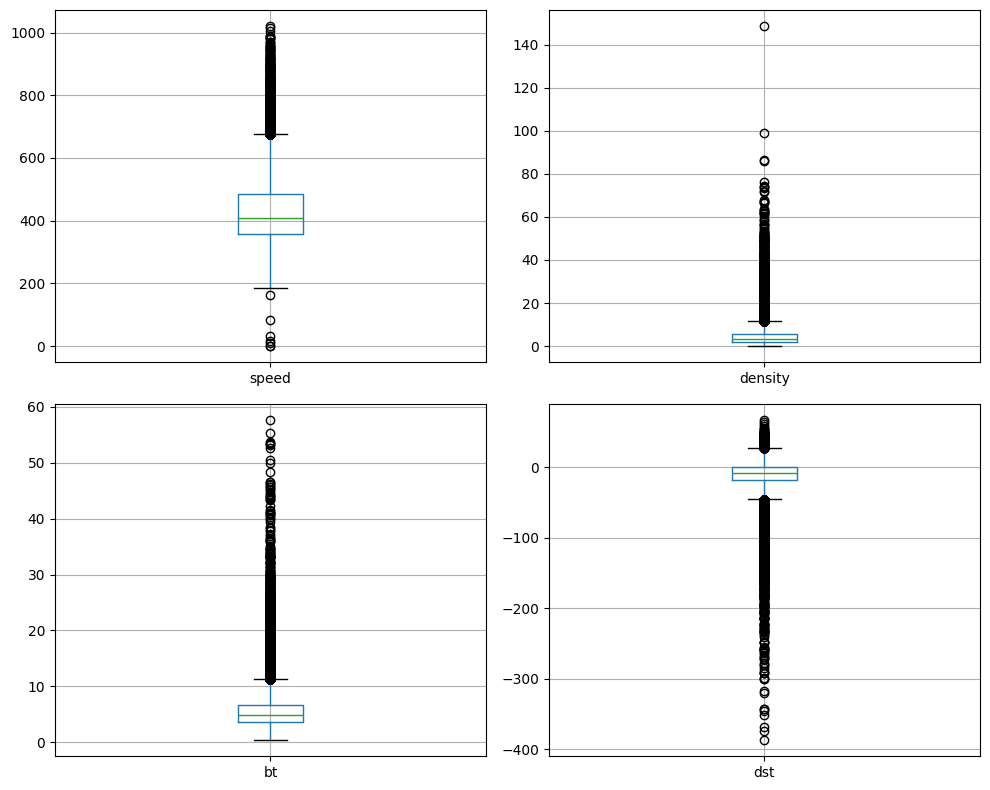

In [139]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

aurora_df.boxplot(column="speed", ax=axes[0,0])
aurora_df.boxplot(column="density", ax=axes[0,1])
aurora_df.boxplot(column="bt", ax=axes[1,0])
aurora_df.boxplot(column="dst", ax=axes[1,1])

plt.tight_layout()
plt.show()

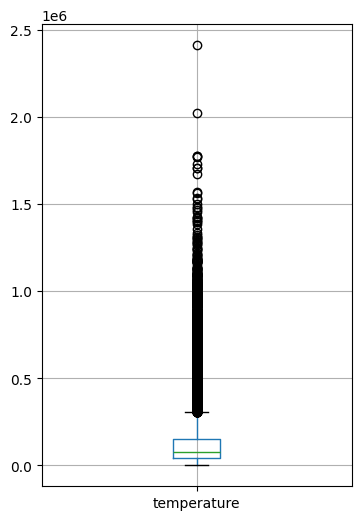

In [140]:
aurora_df.boxplot(column="temperature", figsize=(4,6))
plt.show()

The numerical variables were inspected using boxplots to identify potential anomalous observations.

Several variables contain values outside the interquartile range, particularly **speed**, **density**, **temperature**, **bt**, and **Dst**. However, these observations correspond to the tails of the distributions and may represent periods of unusually intense solar and geomagnetic activity rather than measurement errors.

Since the objective of this project is to predict both typical and extreme geomagnetic conditions, these observations were retained and no outlier removal was performed.

## Train-Test Split

To evaluate the model fairly, the dataset was divided into separate training and testing sets using an **80/20 split**. This ratio provides a good balance between training the model on a large amount of data while reserving a sufficiently large independent test set for a reliable performance evaluation.

The model is trained using **80%** of the observations and evaluated on the remaining **20%**, which contains data that were not seen during training. This provides an unbiased estimate of how well the model is expected to generalise to new space weather observations.

In [141]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [142]:
print(f"Training features: {X_train.shape}")
print(f"Testing features: {X_test.shape}")

print(f"Training target: {y_train.shape}")
print(f"Testing target: {y_test.shape}")

Training features: (111897, 15)
Testing features: (27975, 15)
Training target: (111897,)
Testing target: (27975,)


The dataset was successfully divided into training and testing subsets. The training set will be used to fit the Machine Learning models, while the test set will remain unseen during training and will be used to evaluate the models' predictive performance.

## Machine Learning Approach

Before training the models, it is important to identify the type of machine learning problem being addressed.

This project is a **supervised regression task**. The objective is to predict the **Dst index**, which is a continuous numerical variable representing the intensity of geomagnetic disturbances.

Since the target variable is continuous rather than categorical, regression algorithms were selected instead of classification models. Consequently, the models are evaluated using regression metrics such as **MAE**, **RMSE**, and **R²**, which measure prediction error and explanatory performance.

## Feature Scaling

Although this is a regression task, **not all regression algorithms interpret numerical values in the same way**. Some models are sensitive to the scale of the features, while others are not.

The predictor variables in this dataset are measured in very different units and ranges. For example, **solar wind speed** is measured in hundreds of km/s, whereas the **magnetic field strength** is typically below 20 nT. Without scaling, variables with larger numerical values could dominate the learning process.

Feature scaling is particularly important for **K-Nearest Neighbors (KNN)** because the algorithm measures the distance between observations. If one feature has much larger values than the others, it will have a disproportionate influence on these distances, leading to biased predictions.

To avoid this, the features are standardized using **StandardScaler**, which transforms each variable to have a mean of **0** and a standard deviation of **1**. This places all features on the same scale while preserving the relationships between observations.

Tree-based models such as **Decision Tree** and **Random Forest** do not rely on distances between observations, so feature scaling is not required for those algorithms. Therefore, scaling is only applied to the models that benefit from it.

In [143]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

The scaler was fitted **only on the training set** and then applied to both the training and test sets. This prevents information from the test data from influencing the training process, avoiding **data leakage** and ensuring a fair model evaluation.

## Model Training

### Linear Regression

Linear Regression was selected as the first model because it provides a simple baseline for predicting the Dst index. It assumes a linear relationship between the predictor variables and the target, making it useful as a reference before evaluating more complex Machine Learning models.

In [144]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

lin_reg.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](15,)","[105.24, -2.17, -4.69,..., -8.55, 2.06, -1.42]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-11.06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,15
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(15)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](15,)","[692.06,618.76,447.51,..., 48.77, 33.56, 0.38]"


The model was trained using the scaled training data. During this step, Linear Regression learns how each space weather variable influences the Dst index by assigning a weight to every feature.

### Prediction

In [145]:
y_pred_lr = lin_reg.predict(X_test_scaled)

## Model Evaluation

In [146]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print(f"MAE: {mean_absolute_error(y_test, y_pred_lr):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.2f}")
print(f"R²: {r2_score(y_test, y_pred_lr):.2f}")

MAE: 10.09
RMSE: 15.43
R²: 0.37


The model was evaluated on the unseen test set using three complementary metrics.

The **Mean Absolute Error (MAE)** measures the average prediction error in the same units as the Dst index (nT). An **MAE of 10.09 nT** indicates that, on average, the predicted Dst values differ from the observed values by approximately **10 nT**. Whether this error is acceptable will be assessed by comparing it with the performance of the other models.

The **Root Mean Squared Error (RMSE)** gives greater weight to larger prediction errors. The obtained value of **15.43 nT** suggests that, although the average error is moderate, the model occasionally produces larger deviations.

Finally, the **R² score** measures how much of the variability in the Dst index is explained by the model. An **R² of 0.37** indicates that the Linear Regression model explains approximately **37%** of the observed variability. This result provides a baseline that will be compared with the performance of more advanced models in the following sections.

More flexible Machine Learning models will therefore be evaluated to determine whether they can better capture these complex relationships.

## Model Training

### K-Nearest Neighbors (KNN) Regressor

K-Nearest Neighbors was selected because geomagnetic activity is expected to exhibit similar behaviour under similar solar wind and magnetic field conditions, making a distance-based approach a suitable candidate.

Unlike Linear Regression, KNN is a non-parametric algorithm that does not assume a predefined relationship between the predictor variables and the target.

Instead, it predicts the Dst index by identifying the **k** most similar observations in the training dataset and averaging their Dst values. Since KNN relies on distances between observations, feature scaling is particularly important to ensure that all variables contribute equally.

In this project, k was set to 5, meaning that each prediction is based on the five most similar observations in the training data.

In [147]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


### Prediction

In [148]:
y_pred_knn = knn.predict(X_test_scaled)

## Model Evaluation

In [149]:
print(f"MAE: {mean_absolute_error(y_test, y_pred_knn):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_knn)):.2f}")
print(f"R²: {r2_score(y_test, y_pred_knn):.2f}")

MAE: 8.81
RMSE: 13.67
R²: 0.50


The K-Nearest Neighbors model outperformed the Linear Regression baseline across all evaluation metrics.

The **MAE decreased from 10.09 nT to 8.81 nT**, indicating a lower average prediction error. Similarly, the **RMSE decreased from 15.43 nT to 13.67 nT**, suggesting that the model also reduced larger prediction errors.

Finally, the **R² score increased from 0.37 to 0.50**, meaning that KNN explains approximately **50% of the variability** in the Dst index, compared with **37%** achieved by Linear Regression.

These results indicate that KNN captures the relationship between the space weather variables and the Dst index more effectively than the linear baseline. Nevertheless, additional models will be evaluated to determine whether further improvements can be achieved.

## Effect of the Scaling Method

Since K-Nearest Neighbors relies on distances between observations, its performance may vary depending on the scaling technique used.

To evaluate this effect, the model was trained again using **MinMaxScaler**, which rescales each feature to the range [0, 1]. The results were then compared with those obtained using **StandardScaler**.

In [150]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()

X_train_minmax = minmax.fit_transform(X_train)
X_test_minmax = minmax.transform(X_test)

In [151]:
knn_minmax = KNeighborsRegressor(n_neighbors=5)

knn_minmax.fit(X_train_minmax, y_train)

y_pred_knn_minmax = knn_minmax.predict(X_test_minmax)

In [152]:
print(f"MAE: {mean_absolute_error(y_test, y_pred_knn_minmax):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_knn_minmax)):.2f}")
print(f"R²: {r2_score(y_test, y_pred_knn_minmax):.2f}")

MAE: 8.86
RMSE: 13.69
R²: 0.50


### KNN Standard VS MinMax Scaler

In [153]:
comparison = pd.DataFrame({
    "Scaling Method": ["StandardScaler", "MinMaxScaler"],
    "MAE ↓": [8.81, 8.86],
    "RMSE ↓": [13.67, 13.69],
    "R² ↑": [0.50, 0.50]
})

comparison

,Scaling Method,MAE ↓,RMSE ↓,R² ↑
0,StandardScaler,8.81,13.67,0.5
1,MinMaxScaler,8.86,13.69,0.5


Both scaling techniques produced very similar results. StandardScaler achieved slightly lower MAE and RMSE values while obtaining the same R² score. Therefore, StandardScaler was retained for the remainder of the project.

## Model Training

### Decision Tree Regressor

Decision Trees were selected because they can capture nonlinear relationships and interactions between variables, which are expected in complex space weather processes.

Decision Trees predict the target value by recursively splitting the data into smaller groups based on the predictor variables. Unlike Linear Regression, they can capture nonlinear relationships and interactions between features without requiring a predefined mathematical equation.

In [154]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=42)

tree.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

The model was trained using the **original (unscaled) training data**. Unlike algorithms that benefit from feature scaling, such as **Linear Regression** and **K-Nearest Neighbors**, Decision Trees split the data by selecting threshold values for individual features rather than relying on the magnitude or distance between variables.

As a result, feature scaling does not affect the tree structure or its predictions, making standardization unnecessary for this algorithm.

### Prediction

In [155]:
y_pred_tree = tree.predict(X_test)

## Model Evaluation

In [156]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print(f"MAE: {mean_absolute_error(y_test, y_pred_tree):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_tree)):.2f}")
print(f"R²: {r2_score(y_test, y_pred_tree):.2f}")

MAE: 10.11
RMSE: 17.02
R²: 0.23


The Decision Tree Regressor performed worse than both the Linear Regression baseline and the K-Nearest Neighbors model.

Its **MAE increased to 10.11 nT**, while the **RMSE rose to 17.02 nT**, indicating larger prediction errors on the test set. In addition, the **R² score decreased to 0.23**, meaning that the model explained only **23% of the variability** in the Dst index.

These results suggest that the default Decision Tree did not generalise well to unseen data. A likely explanation is **overfitting**, as unrestricted decision trees tend to fit the training data very closely while performing poorly on new observations. Hyperparameter tuning, such as limiting the tree depth or increasing the minimum number of samples per split, could improve its generalisation performance.

## Model Training

### Random Forest Regressor

Random Forest was selected because it combines the predictions of multiple Decision Trees, reducing overfitting while preserving the ability to capture complex nonlinear relationships between the predictor variables and the Dst index.

In [157]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor(
    n_estimators=25,
    random_state=42,
    n_jobs=-1
)

forest.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",25
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"ma

The model was trained using the **original (unscaled) training data**. Like Decision Trees, Random Forest makes predictions by recursively splitting the data using threshold values rather than distances between observations.

Since feature scaling does not affect these splits, the original training data were used without standardization.

### Prediction

In [158]:
y_pred_forest = forest.predict(X_test)

## Model Evaluation

In [159]:
print(f"MAE: {mean_absolute_error(y_test, y_pred_forest):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_forest)):.2f}")
print(f"R²: {r2_score(y_test, y_pred_forest):.2f}")

MAE: 7.46
RMSE: 11.90
R²: 0.62


The Random Forest Regressor achieved the best performance among all evaluated models.

The **MAE decreased to 7.46 nT**, meaning that the average prediction error was reduced compared with Linear Regression (10.09 nT), K-Nearest Neighbors (8.81 nT), and Decision Tree (10.11 nT). Likewise, the **RMSE decreased to 11.90 nT**, indicating that the model also reduced larger prediction errors.

Finally, the **R² score increased to 0.62**, meaning that the model explained approximately **62% of the variability** in the Dst index. This represents a substantial improvement over Linear Regression (37%), K-Nearest Neighbors (50%), and Decision Tree (23%).

These results suggest that combining multiple Decision Trees enabled the model to capture the complex relationships between the space weather variables and the Dst index more effectively than the previous approaches, while reducing the overfitting observed with a single Decision Tree.

## Feature Importance

Unlike K-Nearest Neighbors, Random Forest can estimate the relative importance of each predictor variable. This helps identify which space weather measurements contribute the most to predicting the Dst index, providing additional insight into the model beyond its predictive performance. 

In the EDA, we observed correlations between variables. Now, we want to determine which ones the model actually considers important for making its predictions.

In [160]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": forest.feature_importances_
})

In [161]:
importance = (
    importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

importance

,Feature,Importance
0,speed,0.248666
1,smoothed_ssn,0.122901
2,bt,0.096219
3,bz_gsm,0.092503
4,temperature,0.081122
5,density,0.077311
6,by_gsm,0.041487
7,by_gse,0.038933
8,bz_gse,0.037869
9,theta_gsm,0.028828


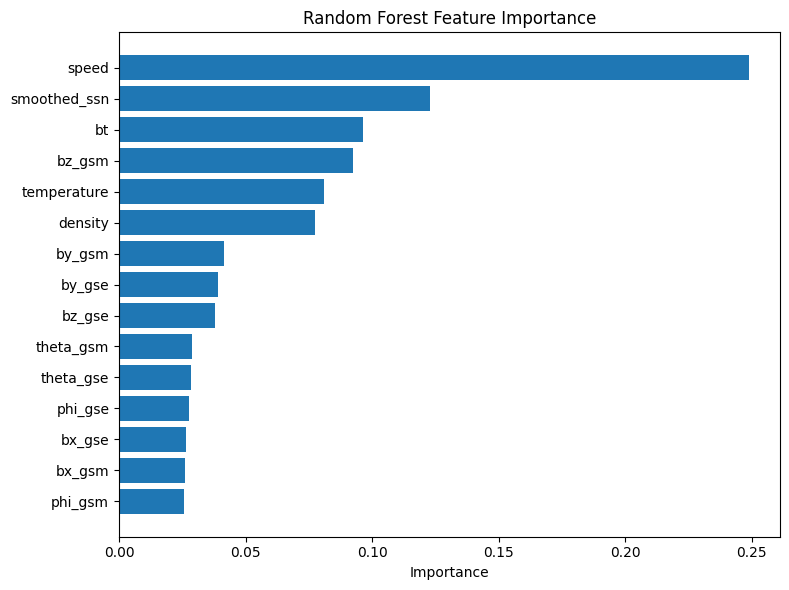

In [162]:
plt.figure(figsize=(8,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

The Random Forest model identified speed as the most influential predictor of the Dst index, followed by smoothed sunspot number (smoothed_ssn), bt, bz_gsm, and temperature. Overall, both solar wind properties and magnetic field measurements contributed substantially to the model's predictions, suggesting that geomagnetic activity depends on a combination of these physical variables rather than a single dominant factor.

## Model Comparison

In [163]:
comparison = pd.DataFrame({
    "Rank": ["🥇", "🥈", "🥉", "4️⃣"],
    "Model": ["Random Forest", "KNN", "Linear Regression", "Decision Tree"],
    "MAE": [7.46, 8.81, 10.09, 10.11],
    "RMSE": [11.90, 13.67, 15.43, 17.02],
    "R²": [0.62, 0.50, 0.37, 0.23]
})

comparison

,Rank,Model,MAE,RMSE,R²
0,🥇,Random Forest,7.46,11.90,0.62
1,🥈,KNN,8.81,13.67,0.50
2,🥉,Linear Regression,10.09,15.43,0.37
3,4️⃣,Decision Tree,10.11,17.02,0.23


The comparison shows a clear improvement in predictive performance from Linear Regression to Random Forest.

Among all evaluated models, **Random Forest achieved the lowest prediction errors (MAE and RMSE) and the highest R² score**, making it the best-performing model for predicting the Dst index. K-Nearest Neighbors ranked second, while Decision Tree performed the worst despite its ability to capture nonlinear relationships, suggesting that a single tree was more prone to overfitting.

Overall, these results indicate that **ensemble methods** provide a more accurate and robust approach for modelling geomagnetic activity than either linear or single-tree models.

## Hyperparameter Tuning

### RandomizedSearchCV

The default Random Forest model already achieved the best performance among the evaluated algorithms. However, its performance may be further improved by optimizing its hyperparameters.

Instead of testing every possible combination, **RandomizedSearchCV** was used to efficiently explore different parameter values. This approach evaluates a random subset of combinations, making it faster while still identifying high-performing configurations.

In [164]:
X_train.shape

(111897, 15)

The hyperparameter search space was defined by selecting a range of values for the main Random Forest parameters. These combinations will be explored to identify the configuration that provides the best predictive performance.

In [166]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [25, 50],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

A Randomized Search was performed to evaluate different hyperparameter combinations using 3-fold cross-validation.  To reduce computational time, the search was carried out on a representative sample of the training data.

In [167]:
random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [25, 50]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluati

In [168]:
X_sample = X_train.sample(n=30000, random_state=42)
y_sample = y_train.loc[X_sample.index]

random_search.fit(X_sample, y_sample)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [25, 50]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluati

Once the search was completed, the best-performing hyperparameter combination was retrieved together with its average cross-validation R² score.

In [169]:
random_search.best_params_

{'n_estimators': 50,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_depth': 20}

In [170]:
random_search.best_score_

np.float64(0.47026537986881367)

The best-performing Random Forest model identified during the search was selected for the final evaluation.

In [171]:
best_forest = random_search.best_estimator_

The selected model was then retrained using the complete training dataset to maximize the amount of information available before making predictions on the unseen test set.

In [172]:
best_forest.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of t

The optimized model was used to predict the Dst values for the unseen test set.

In [174]:
y_pred_best = best_forest.predict(X_test)

In [175]:
print(f"MAE: {mean_absolute_error(y_test, y_pred_best):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best)):.2f}")
print(f"R²: {r2_score(y_test, y_pred_best):.2f}")

MAE: 7.77
RMSE: 12.12
R²: 0.61


The optimized Random Forest model was evaluated on the unseen test set and compared with the baseline model.

Although RandomizedSearchCV identified a different combination of hyperparameters, the optimized model produced slightly higher MAE and RMSE values and a marginally lower R² score. Therefore, hyperparameter tuning did not improve the model's predictive performance.

As a result, the original Random Forest model was retained as the final model for deployment in the Streamlit application.

As RandomizedSearchCV did not produce a better-performing model, there was little justification for carrying out a more computationally expensive GridSearchCV. The additional training time was unlikely to result in meaningful performance gains, so the baseline Random Forest was retained.

### Gradient Boosting Regressor

Gradient Boosting was selected because it builds Decision Trees sequentially, with each new tree learning from the errors made by the previous ones. This often leads to higher predictive accuracy than a single Decision Tree or even a Random Forest, particularly when the relationships between features and the target are complex.

In [176]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)
 
gbr.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

The model was trained using the **original (unscaled) training data**. Like Decision Trees and Random Forest, Gradient Boosting is based on decision trees and therefore does not rely on distances between observations.

Instead, it improves performance by building a sequence of trees, where each new tree focuses on correcting the prediction errors made by the previous ones. As a result, feature scaling is not required.

In [177]:
y_pred_gbr = gbr.predict(X_test)

In [178]:
print(f"MAE: {mean_absolute_error(y_test, y_pred_gbr):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_gbr)):.2f}")
print(f"R²: {r2_score(y_test, y_pred_gbr):.2f}")

MAE: 9.40
RMSE: 14.27
R²: 0.46


The Gradient Boosting Regressor was evaluated using the same metrics as the previous models.

Although Gradient Boosting is often capable of achieving high predictive accuracy by sequentially correcting previous errors, it did not outperform the Random Forest model in this dataset. It produced higher MAE and RMSE values together with a lower R² score.

Therefore, the Random Forest Regressor remained the best-performing model and was selected as the final model for deployment in the Streamlit application.

## Model Comparison: Baseline vs Tuned Random Forest

In [179]:
comparison_rf = pd.DataFrame({
    "Model": ["Random Forest", "Tuned Random Forest"],
    "MAE": [7.46, 7.77],
    "RMSE": [11.90, 12.12],
    "R²": [0.62, 0.61]
})

comparison_rf

,Model,MAE,RMSE,R²
0,Random Forest,7.46,11.90,0.62
1,Tuned Random Forest,7.77,12.12,0.61


The baseline and optimized Random Forest models were compared to evaluate the impact of hyperparameter tuning.

Although RandomizedSearchCV identified a different combination of hyperparameters, the tuned model produced slightly higher MAE and RMSE values together with a marginally lower R² score. Therefore, hyperparameter tuning did not improve the model's predictive performance.

As a result, the baseline Random Forest remained the best-performing model and was selected as the final model for deployment in the Streamlit application.

## Final Conclusion

Throughout this project, several regression algorithms were evaluated to predict the Dst index using space weather measurements.

Linear Regression established a simple baseline, while K-Nearest Neighbors and Decision Tree explored alternative approaches capable of modelling more complex relationships. Among all the evaluated models, **Random Forest consistently achieved the best predictive performance**, obtaining the lowest MAE and RMSE values together with the highest R² score.

To further improve the model, a **Randomized Search** was performed to optimize its hyperparameters. However, after comparing the baseline and tuned versions, the optimized model did not outperform the original Random Forest. Consequently, the **baseline Random Forest was selected as the final model** for this project.

At this stage, the machine learning pipeline is complete. A reliable predictive model has been trained, evaluated and selected.

The next step is to move from experimentation to deployment by integrating this model into a **Streamlit application** where real-time NOAA solar wind, magnetic field and solar activity measurements are used to generate Today's ML Aurora Estimate through the trained Random Forest model. Alongside this real-time ML component, the application provides forecasts for selected locations and dates using the NOAA 45-Day Space Weather Forecast together with darkness, cloud cover and visibility data from external APIs.

This transition demonstrates how a machine learning model can evolve from a research notebook into the core component of a real-world predictive application, transforming raw space weather data into meaningful insights that help users plan their chances of experiencing the Northern Lights.

In [183]:
import joblib

joblib.dump(forest, "random_forest_model.pkl")

['random_forest_model.pkl']

In [184]:
joblib.dump(list(X.columns), "model_columns.pkl")

['model_columns.pkl']

In [1]:
import joblib

model = joblib.load("random_forest_model.pkl")
joblib.dump(model, "random_forest_model_compressed.pkl", compress=9)

['random_forest_model_compressed.pkl']